In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [17]:
path_input = '../data/'
path_output = '../figures/'

In [18]:
ds_GS2 = xr.open_dataset(path + 'Gulf_stream_paired_review.nc')
ds_AGULHAS = xr.open_dataset(path + 'Agulhas_paired_review.nc')
ds_CCS = xr.open_dataset(path + 'CCS_paired_review.nc')
ds_ACC1 = xr.open_dataset(path + 'ACC1_paired_review.nc')
ds_ACC2 = xr.open_dataset(path + 'ACC2_paired_review.nc')
ds_MED = xr.open_dataset(path + 'MED_paired_review.nc')

In [19]:
props = dict(boxstyle='round', facecolor='w', pad = 0.1, ls = '--')


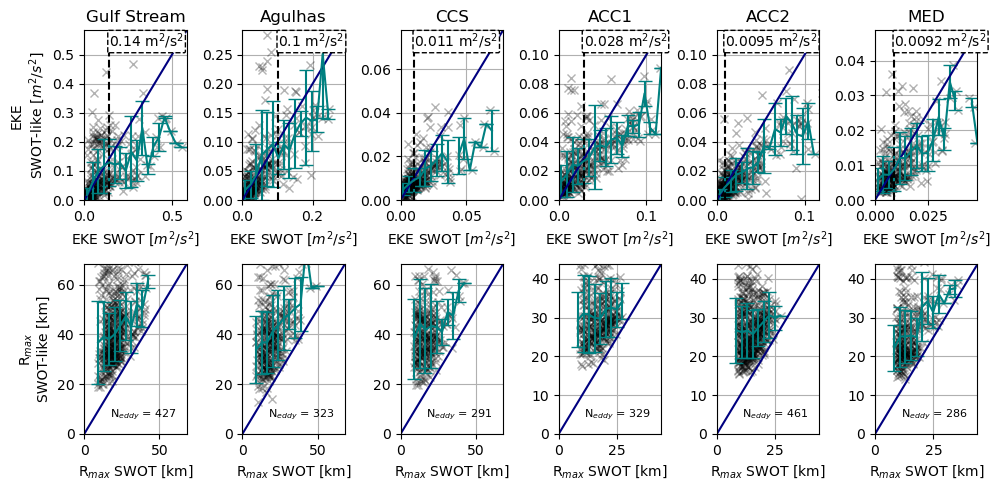

In [20]:

cases = ['Gulf_Stream', 'Agulhas', 'CCS', 'ACC1', 'ACC2', 'MED']
eke_max = [0.6, .3, .08, .12, .12, .05]
rmax = [70, 70, 70, 45, 45, 45]
rmin = 0

cpt = 0
fig, axes = plt.subplots(ncols = 6, nrows = 2, figsize = (10, 5))

for case in cases:


    ds = xr.open_dataset(path + f'{case}_paired_review.nc')

    filter_eddies_rmax_swot = ds.rmax_swot[ds.rmax_swot>9]
    filter_eddies_rmax_duacs = ds.rmax_duacs[ds.rmax_swot>9]
    
    filter_eddies_eke_swot = ds.eke_swot[ds.rmax_swot>9]
    filter_eddies_eke_duacs = ds.eke_duacs[ds.rmax_swot>9]

    Neddy = len(filter_eddies_rmax_swot)
    
    bins_eke = np.linspace(0, eke_max[cpt], 20) # AGULHAS
    bins_center_eke = (bins_eke[:-1]+ bins_eke[1:])/2
    
    
    bins_rmax = np.linspace(0, rmax[cpt], 20) # AGULHAS
    bins_center_rmax = (bins_rmax[:-1]+ bins_rmax[1:])/2




    y_mean_rmax, y_std_rmax, n = bin_average(filter_eddies_rmax_swot, filter_eddies_rmax_duacs, bins_rmax)
    y_mean_eke, y_std_eke, n = bin_average(filter_eddies_eke_swot, filter_eddies_eke_duacs, bins_eke)
    
    
    # get the separation for eke
    mask = (y_mean_eke) < bins_center_eke
    i0 = np.where(mask)[0][0]
    x_cross = bins_center_eke[i0]


    
    ax = axes[0][cpt]
    ax.plot(filter_eddies_eke_swot, filter_eddies_eke_duacs, marker = 'x', lw = 0, color = 'k', alpha = .3)
    ax.errorbar(bins_center_eke, y_mean_eke, yerr = y_std_eke, capsize = 5, color = 'teal')
    ax.plot([0, np.amax(bins_center_eke)], [0, np.amax(bins_center_eke)], color = 'navy')
    ax.set_xlim([0, np.amax(bins_center_eke)])
    ax.set_ylim([0, np.amax(bins_center_eke)])
    # ax.set_aspect('equal', 'box')
    ax.axvline(x_cross, color = 'k', ls = '--')
    ax.text(x_cross, np.nanpercentile(bins_center_eke, 90), f'{x_cross:.2} m$^{{2}}$/s$^{{2}}$', bbox = props)

    ax.set_title(f'{case}')
    ax.set_xlabel('EKE SWOT [$m^{2}/s^{2}$]')
    if cpt == 0:
        ax.set_ylabel('EKE\nSWOT-like [$m^{2}/s^{2}$]')
        ax.set_title('Gulf Stream')
    ax.grid()

    ax = axes[1][cpt]
    ax.plot(filter_eddies_rmax_swot,filter_eddies_rmax_duacs, marker = 'x', lw = 0, color = 'k', alpha = .3)
    ax.errorbar(bins_center_rmax, y_mean_rmax, yerr = y_std_rmax, capsize = 5, color = 'teal')
    ax.plot([0, np.amax(bins_center_rmax)], [0, np.amax(bins_center_rmax)], color = 'navy')

    ax.set_xlim([0, np.amax(bins_center_rmax)])
    ax.set_ylim([0, np.amax(bins_center_rmax)])
    # ax.set_aspect('equal', 'box')
    ax.text(.25, 0.1, f'N$_{{eddy}}$ = {Neddy}', transform = ax.transAxes, fontsize = 8)
    ax.set_xlabel('R$_{max}$ SWOT [km]')
    

    if cpt == 0:
        ax.set_ylabel('R$_{max}$\nSWOT-like [km]')

    ax.grid()

    cpt = cpt + 1
plt.tight_layout()
# plt.savefig(path_output + 'Fig_S6.png', dpi = 300, bbox_inches = 'tight')


In [21]:
def bin_average(swot_data, duacs_data, bins):
    x = np.array(swot_data)
    y = np.array(duacs_data)

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Bin definition
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Assign each point to a bin
    ind = np.digitize(x, bins)
    
    # Compute statistics
    y_mean = np.full(len(bin_centers), np.nan)
    y_std  = np.full(len(bin_centers), np.nan)
    n      = np.zeros(len(bin_centers), dtype=int)
    
    for i in range(len(bin_centers)):
        m = ind == i + 1
        if np.any(m):
            y_mean[i] = np.mean(y[m])
            y_std[i]  = np.std(y[m])
            n[i]      = np.sum(m)
    return y_mean, y_std, n